Modules
==============================

In [1]:
using LinearAlgebra
BLAS.set_num_threads(1)

using FFTW
FFTW.set_num_threads(5)

using XFields
using CMBrings
using CMBsphere
using CMBflat: PrQr # Eventually remove this

import FFTransforms as FT
import SphereTransforms as ST

using Spectra
using FieldLensing

using  LinearAlgebra
using  SparseArrays
import Dierckx
import NLopt

using DelimitedFiles
using LBblocks: @sblock
using PyPlot
using BenchmarkTools
using ProgressMeter

In [2]:
if isdefined(Main,:PlutoRunner)
    import PlutoUI
    hide_plots = false
elseif isdefined(Main, :IJulia) && Main.IJulia.inited
    hide_plots = false
else
    hide_plots = true
end

false

Set ring transforms
==============================

In [3]:
tmUS0, tmUS2, θ, φ, Ω, ringidx, tmS0 = @sblock let

    # size of the embedding full sphere
    # 𝕊nθ, 𝕊nφ = (3584, 4096-1)
    𝕊nθ, 𝕊nφ = (4096, 4096-1)

    # grid coords on full sphere
    θ𝕊, φ𝕊  = ST.pix(𝕊nθ, 𝕊nφ)

    # north and southern boundaries and the corresponding indices
    # Small strip at full resolution
    θnorth∂ = 2.5 #
    θsouth∂ = 2.72 # 2.7
   
    θrng    = findall(θnorth∂ .<= θ𝕊 .<= θsouth∂)
    ringidx = CartesianIndices((θrng[1]:θrng[end], 1:length(φ𝕊)))

    nθ, nφ  = size(ringidx)
    θ, φ  = θ𝕊[ringidx[:,1]], φ𝕊
    Ω     = ST.Ωpix(𝕊nθ, 𝕊nφ)[ringidx[:,1]]

    # Unitary transforms for spin0 and spin2
    T = Float64
    # T = Float32
    tmS0 = FT.:⊗(FT.𝕀(nθ), FT.𝕎(T, nφ, 2π)) |> x -> FT.unitary_scale(x)*x
    tmUS0 = FT.:⊗(FT.𝕀(nθ), FT.𝕎(Complex{T}, nφ, 2π)) |> x -> FT.unitary_scale(x)*x
    tmUS2 = FT.:⊗(FT.𝕀(nθ), FT.𝕎(Complex{T}, nφ, 2π)) |> x -> FT.unitary_scale(x)*x

    return tmUS0, tmUS2, θ, φ, Ω, ringidx, tmS0
end;

Mask and CMBring observation region
==============================

In [4]:
data_mask_init = @sblock let θ, φ

    # Default:
    pr_mat_init  = readdlm(joinpath(CMBrings.module_dir,"examples/artifacts/FastTransform_mask_nθ3072_nφ4095.csv"), ',', Bool)
    # Near-south pole mask:
    # pr_mat_init  = readdlm(joinpath(CMBrings.module_dir,"examples/artifacts/FastTransform_mask_mid2pole_nθ2560_nφ3071.csv"), ',', Bool)
    # South pole mask:
    # pr_mat_init  = readdlm(joinpath(CMBrings.module_dir,"examples/artifacts/FastTransform_mask_spole_nθ3072_nφ4095.csv"), ',', Bool)

    θ_mat_init, φ_mat_init = ST.pix(size(pr_mat_init)...)
    spline_mask = Dierckx.Spline2D(θ_mat_init, φ_mat_init, pr_mat_init, kx=1, ky=1, s=0.0)

    data_mask_init = spline_mask.(θ, φ') .> 0
    data_mask_init[1:15,:] .= 0
    data_mask_init[end - 15 + 1:end,:] .= 0


    return data_mask_init

end;

Internal error: encountered unexpected error in runtime:
StackOverflowError()


In [5]:
Pr, Qr = @sblock let tmUS2, θ, φ, data_mask_init, QP_bdry=1e-5, fwhm′=150
    tmFlat = FT.𝕎(real(eltype_in(tmUS2)), size(data_mask_init), ((θ[2] - θ[1])*length(θ), 2π))
    pr0x, qr0x = PrQr(tmFlat, data_mask_init, fwhm′, fwhm′, QP_bdry)
    pr0 = Xmap(tmUS2, pr0x)
    qr0 = Xmap(tmUS2, qr0x)
    DiagOp(pr0), DiagOp(qr0)
end;

Localize lensing vector field to data mask.

In [6]:
Mϕ = @sblock let tmS0, θ, φ, data_mask_init, QP_bdry=1e-5, fwhm′=75
    tmFlat = FT.𝕎(real(eltype_in(tmS0)), size(data_mask_init), ((θ[2] - θ[1])*length(θ), 2π))
    pr0x, qr0x = PrQr(tmFlat, data_mask_init, fwhm′, fwhm′, QP_bdry)

    # mϕx = pr0x .+ qr0x
    mϕx = pr0x

    # make sure it hits zero and 1
    mϕx .-= minimum(mϕx)
    mϕx ./= maximum(mϕx)
    Mϕ    = DiagOp(Xmap(tmS0, mϕx))
    Mϕ
end;

Azimuthal ring mask

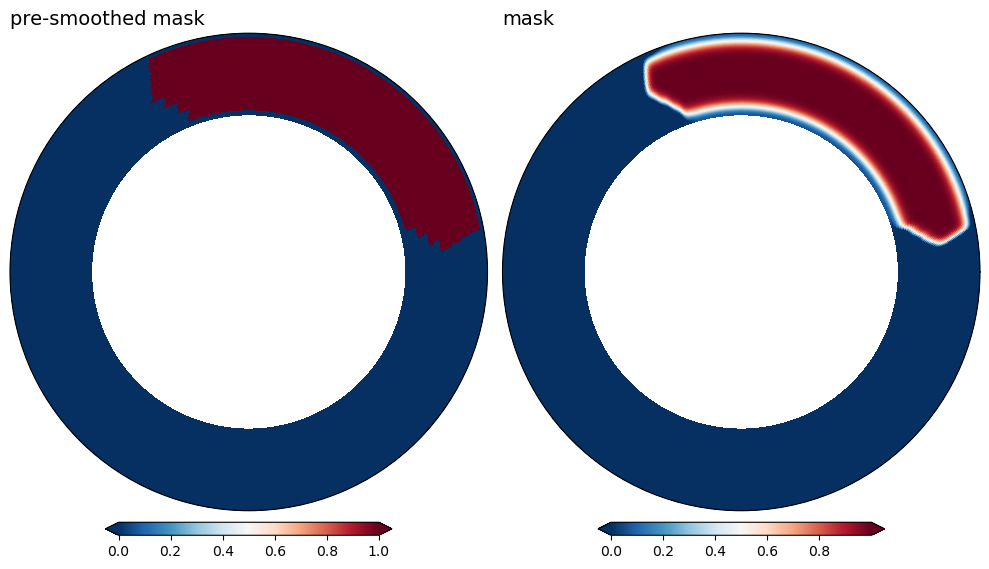

In [7]:
@sblock let ma=real.(Pr[:]), dma=data_mask_init, φ, θ, hide_plots
    hide_plots && return
    imgs = Dict(1=>dma, 2=>ma)
    txt  = Dict(1=>"pre-smoothed mask", 2=>"mask")
    fig, ax = CMBrings.diskplot(
        imgs, φ', π.-θ;
        txt=txt,
        figsize=(10,8), nrows=1, fontsize=14
    )
    return nothing
end

Plot √Ωpix over ring θ's

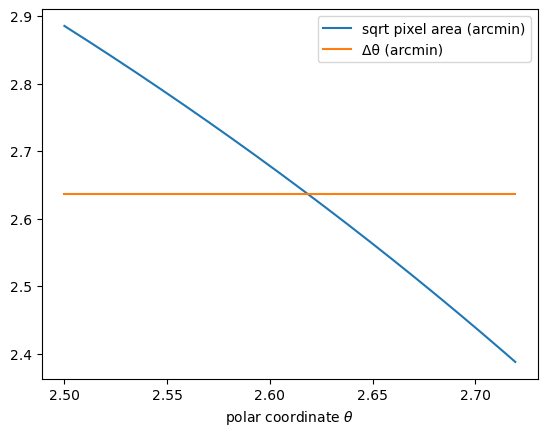

In [8]:
@sblock let θ, φ, Ω, hide_plots
    hide_plots && return
    fig,ax = subplots(1)
    ax.plot(θ, rad2deg.(sqrt.(Ω)).*60, label="sqrt pixel area (arcmin)")
    ax.plot(θ, zero(θ) .+ rad2deg.(θ[2] - θ[1]).*60, label="Δθ (arcmin)")
    # ax.plot(θ, zero(θ) .+ rad2deg.(φ[2] - φ[1]).*60, label="Δφ (arcmin)")
    ax.set_xlabel(L"polar coordinate $\theta$")
    ax.legend()
    return nothing
end

In [9]:
(length(θ), length(φ))

(287, 4095)

Spectral densities
==============================

ϕϕ, EB spectra

In [10]:
eeℓ, bbℓ, ẽeℓ, b̃bℓ, ϕϕℓ, ℓvec = @sblock let

    r  = 0.01

    lmax = 11000
    l = 0:lmax
    cld = Spectra.camb_cls(;lmax=lmax, r)

    eesl = cld[:unlen_scalar] |> x->(x[:Cee] ./ x[:factor_on_cl_cmb])
    eetl = cld[:unlen_tensor] |> x->(x[:Cee] ./ x[:factor_on_cl_cmb])
    eel  = eesl .+ eetl
    eel[1] = 0

    bbsl = cld[:unlen_scalar] |> x->(x[:Cbb] ./ x[:factor_on_cl_cmb])
    bbtl = cld[:unlen_tensor] |> x->(x[:Cbb] ./ x[:factor_on_cl_cmb])
    # note: bbsl == 0
    bbl    = bbsl .+ bbtl
    bbl[1] = 0

    ẽesl   = cld[:len_scalar] |> x->(x[:Cee] ./ x[:factor_on_cl_cmb])
    ẽel    = ẽesl .+ eetl # we only have lensed spectra for scalar
    ẽel[1] = 0

    b̃bsl   = cld[:len_scalar] |> x->(x[:Cbb] ./ x[:factor_on_cl_cmb])
    b̃bl    = b̃bsl .+ eetl # we only have lensed spectra for scalar
    b̃bl[1] = 0

    ϕϕl    = cld[:phi] |> x->(x[:Cϕϕ] ./ x[:factor_on_cl_phi])
    ϕϕl[1] =  0

    return eel, bbl, ẽel, b̃bl, ϕϕl, l

end;

EB ring operator
==============================

In [11]:
EB_ring = @sblock let  eeℓ, bbℓ, ℓvec, θ, φ,

    covPβ = Spectra.βcovSpin2(ℓvec, eeℓ, bbℓ;
        # n_grid::Int = 100_000,
        # β_grid = range(0, π^(1/3), length=n_grid).^3,
    );

    nθ = length(θ)
    nφ = length(φ)

    ptmW = FT.FFTW.plan_fft(Vector{ComplexF64}(undef, nφ), flags=FT.FFTW.MEASURE)
    Γdjk = zeros(ComplexF64, nφ)
    Cdjk = zeros(ComplexF64, nφ)

    # T = ComplexF32
    T = ComplexF64
    Γdb  = Matrix{T}[zeros(T, nθ, nθ) for ℓ = 1:nφ]
    Cdb  = Matrix{T}[zeros(T, nθ, nθ) for ℓ = 1:nφ]

    prgss = Progress(nθ, 1, "Computing EB cov operator ...")
    for k = 1:nθ
        for j = 1:nθ
            θ1, θ2, φ1 = θ[j], θ[k], φ[1]
            β  =  Spectra.geoβ.(θ1, θ2, φ1, φ)
            covPP̄, covPP = covPβ(β)
            covPP̄ .*= Spectra.multPP̄.(θ1, θ2, φ1, φ)
            covPP .*= Spectra.multPP.(θ1, θ2, φ1, φ)
            mul!(Γdjk, ptmW, covPP̄)
            mul!(Cdjk, ptmW, covPP)
            for ℓ = 1:nφ
                @inbounds Γdb[ℓ][j,k] = Γdjk[ℓ]
                @inbounds Cdb[ℓ][j,k] = Cdjk[ℓ]
            end
        end
        next!(prgss)
    end

    return CMBrings.ComplexCircRings(Γdb, Cdb)
end;

Computing EB cov operator ...100%|██████████████████████| Time: 0:01:57


Beam
==============================

In [12]:
beamℓ = @sblock let ℓvec
    beamfwhm     = 3.0 |> arcmin -> deg2rad(arcmin/60)
    # beamfwhm  = 25.0 |> arcmin -> deg2rad(arcmin/60)

    σ² = beamfwhm^2 / 8 / log(2)
    bℓ = @. exp( - σ²*ℓvec*(ℓvec+1) / 2)

    # ℓcut = 200
    # bℓ .*= ℓvec .< ℓcut

    return bℓ
end;

Beam_ring = @sblock let beamℓ, ℓvec, θ, φ, Ω

    covBeamβ = Spectra.βcovSpin0(ℓvec, beamℓ)

    nθ=length(θ)
    nφ=length(φ)

    ptmW = FT.FFTW.plan_fft(Vector{ComplexF64}(undef, nφ), flags=FT.FFTW.MEASURE)
    Γdjk = zeros(ComplexF64, nφ)

    # T    = Float32
    T    = Float64
    Γdb  = Matrix{T}[zeros(T, nθ, nθ) for ℓ = 1:nφ]
    Cdb  = typeof(false*I(nθ))[false*I(nθ) for ℓ = 1:nφ]

    prgss = Progress(nθ, 1, "Computing the beam operator ...")
    for k = 1:nθ
        for j = 1:nθ
            θ1, θ2, φ1 = θ[j], θ[k], φ[1]
            Ωk    = Ω[k]
            β     =  Spectra.geoβ.(θ1, θ2, φ1, φ)
            covIĪ = complex.(covBeamβ(β))
            mul!(Γdjk, ptmW, covIĪ)
            for ℓ = 1:nφ
                @inbounds Γdb[ℓ][j,k] = real(Γdjk[ℓ]) * Ωk
            end
        end
        next!(prgss)
    end

    return CMBrings.ComplexCircRings(Γdb, Cdb)
end;

Computing the beam operator ...100%|████████████████████| Time: 0:00:53


Noise
==============================

In [13]:
Noise_ring, μK′n = @sblock let μK′n = 1.5, θ, φ, Ω

    # T = Float32
    T = Float64
    nθ=length(θ)
    nφ=length(φ)

    μKᵒn = μK′n / 60
    σ²   = deg2rad(μKᵒn)^2
    σ²_Ω = T.(σ²./Ω)

    Γdb  = typeof(Diagonal(σ²_Ω))[Diagonal(σ²_Ω) for ℓ = 1:nφ]
    Cdb  = typeof(false*I(nθ))[false*I(nθ) for ℓ = 1:nφ]

    return CMBrings.ComplexCircRings(Γdb, Cdb), μK′n
end;

Φ operator
==============================

In [14]:
Φ_ring = @sblock let ϕϕℓ, ℓvec, θ, φ, Ω

    covΦβ = Spectra.βcovSpin0(ℓvec, ϕϕℓ)
    nθ=length(θ)
    nφ=length(φ)

    ptmW = FT.FFTW.plan_fft(Vector{ComplexF64}(undef, nφ), flags=FT.FFTW.MEASURE)
    Γdjk = zeros(ComplexF64, nφ)

    # T    = Float32
    T    = Float64
    Γdb  = Matrix{T}[zeros(T, nθ, nθ) for ℓ = 1:nφ]
    # Cdb  = Matrix{T}[zeros(T, nθ, nθ) for ℓ = 1:nφ]
    Cdb  = typeof(false*I(nθ))[false*I(nθ) for ℓ = 1:nφ]

    prgss = Progress(nθ, 1, "Computing the Φ operator ...")
    for k = 1:nθ
        for j = 1:nθ
            θ1, θ2, φ1 = θ[j], θ[k], φ[1]
            Ωk    = Ω[k]
            β     =  Spectra.geoβ.(θ1, θ2, φ1, φ)
            covIĪ = complex.(covΦβ(β))
            mul!(Γdjk, ptmW, covIĪ)
            for ℓ = 1:nφ
                # TODO: double check this ....
                # @inbounds Γdb[ℓ][j,k] = real(Γdjk[ℓ] / 2)
                # @inbounds Cdb[ℓ][j,k] = real(Γdjk[ℓ] / 2)
                @inbounds Γdb[ℓ][j,k] = real.(Γdjk[ℓ])
            end
        end
        next!(prgss)
    end

    return CMBrings.ComplexCircRings(Γdb, Cdb)
end;

Computing the Φ operator ...100%|███████████████████████| Time: 0:00:52


Gradients Set sparse increment matrices for non-FFT lensing
==================================================

In [15]:
function generate_∇!_∇!ϕ_1storder(tmS0::Transform{Tf,d}, θℝ, φℝ) where {Tf,d}
    Δθℝ, Δφℝ = θℝ[2] - θℝ[1], φℝ[2] - φℝ[1]

    ∂θ′ = spdiagm(
            0 => fill(-1,length(θℝ)),
            1 => fill(1,length(θℝ)-1),
        )
    ∂θ′[end,1] =  1
    ∂θ = Tf(1 / (Δθℝ)) * ∂θ′
   

    ∂φ  = spdiagm(
        0 => fill(-1,length(φℝ)),
        1 => fill(1,length(φℝ)-1)
    )
    ∂φ[end,1] =  1
    ∂φᵀ = transpose(Tf(1 / (Δφℝ)) * ∂φ)
    
    ∇!   = CMBrings.Nabla!((∂θ - ∂θ')/2, (∂φᵀ - ∂φᵀ')/2)
    ∇!_ϕ = CMBrings.Nabla!(∂θ, ∂φᵀ)

    return ∇!, ∇!_ϕ
end


function generate_lense_sublense(;
        tmS0, θ, mv1x=1, mv2x=1,
        ∇!,  ∇!_ϕ, ## subidx, sub_∇!,
        nsteps_lensing=14
        )

    # ∇!_ϕ used in ϕ2v! and ϕ2vᴴ!
    # ∇! used in Ł
    # sub_∇! used in sub_Ł

    sin⁻²θ = @. csc(θ)^2
    mvx₁ = ones(size(θ)) .* mv1x
    mvx₂ = sin⁻²θ .* mv2x

    ϕ2v! = function (v::NTuple{2,Array}, ϕ::Array)
        ∇!_ϕ(v, ϕ)
        v[1] .*= mvx₁
        v[2] .*= mvx₂
        v
    end

    ϕ2vᴴ! = function (ϕ::Array, v::NTuple{2,Array})
        mv = (similar(v[1]), similar(v[2]))
        ∇!_ϕ'(mv, (mvx₁.*v[1], mvx₂.*v[2]) )
        ϕ .= mv[1] .+ mv[2]
        ϕ
    end

    Ł = function (ϕ_az::Xfield)
        ϕ = ϕ_az[:]
        v = (similar(ϕ), similar(ϕ))
        ϕ2v!(v,ϕ)
        FieldLensing.ArrayLense(v, ∇!, 0, 1, nsteps_lensing)
    end

    Ł, ϕ2v!, ϕ2vᴴ!, ∇!
end

∇!,  ∇!_ϕ = generate_∇!_∇!ϕ_1storder(tmS0, θ, φ)

Ł, ϕ2v!, ϕ2vᴴ!, ∇! = generate_lense_sublense(;
        tmS0=tmS0, θ=θ,
        mv1x=Mϕ[:], mv2x=Mϕ[:],
        ∇!,  ∇!_ϕ, ## subidx, sub_∇!,
        nsteps_lensing=11
);

simulation
==============================

In [16]:
@time qu = CMBrings.map_ring(
    (fℓ, Σℓ) -> sqrt(Hermitian(Σℓ)) * fℓ,
    Xmap(tmUS2, randn(eltype_in(tmUS2), size_in(tmUS2))),
    EB_ring,
)

@time no = CMBrings.map_ring(
    (fℓ, Σℓ) -> sqrt(Hermitian(Matrix(Σℓ))) * fℓ,
    Xmap(tmUS2, randn(eltype_in(tmUS2), size_in(tmUS2))),
    Noise_ring,
)

@time ϕ = CMBrings.map_ring(
    (fℓ, Σℓ) -> sqrt(Symmetric(Matrix(Σℓ))) * fℓ,
    Xmap(tmS0, randn(eltype_in(tmS0), size_in(tmS0))),
    Φ_ring,
)

d = Pr * (Beam_ring * Ł(ϕ) * qu + no)

 90.767483 seconds (6.70 M allocations: 66.800 GiB, 1.32% gc time, 0.34% compilation time)
 23.508094 seconds (11.61 M allocations: 31.550 GiB, 3.41% gc time, 5.90% compilation time)
 29.186547 seconds (2.44 M allocations: 52.325 GiB, 3.41% gc time, 0.25% compilation time)


Xmap{FFTransforms.𝕎{ComplexF64, 2, Float64, Float64}, ComplexF64, ComplexF64, 2}(FFTransforms.𝕎{ComplexF64, 2, Float64, Float64}((287, 4095), (false, true), 0.015626907697949846, (287.0, 6.283185307179586)), ComplexF64[0.0 - 0.0im 0.0 - 0.0im … 0.0 + 0.0im 0.0 - 0.0im; 0.0 - 0.0im 0.0 - 0.0im … 0.0 + 0.0im 0.0 - 0.0im; … ; 0.0 + 0.0im 0.0 + 0.0im … 0.0 + 0.0im 0.0 - 0.0im; 0.0 - 0.0im 0.0 - 0.0im … 0.0 - 0.0im 0.0 - 0.0im])

MixFlow
==============================

In [17]:
Ð⁻¹ = @sblock let ẽeℓ, b̃bℓ, ℓvec, θ, φ, EB_ring, Noise_ring

    covPβ = Spectra.βcovSpin2(ℓvec, ẽeℓ, b̃bℓ)

    nθ = length(θ)
    nφ = length(φ)

    ptmW = FT.FFTW.plan_fft(Vector{ComplexF64}(undef, nφ), flags=FT.FFTW.MEASURE)
    Γdjk = zeros(ComplexF64, nφ)
    Cdjk = zeros(ComplexF64, nφ)
    # T    = ComplexF32
    T    = ComplexF64
    Γdb  = Matrix{T}[zeros(T, nθ, nθ) for ℓ = 1:nφ]
    Cdb  = Matrix{T}[zeros(T, nθ, nθ) for ℓ = 1:nφ]

    prgss = Progress(nθ, 1, "Computing EB̃_ring operator ...")
    for k = 1:nθ
        for j = 1:nθ
            θ1, θ2, φ1 = θ[j], θ[k], φ[1]
            β  =  Spectra.geoβ.(θ1, θ2, φ1, φ)
            covPP̄, covPP = covPβ(β)
            covPP̄ .*= Spectra.multPP̄.(θ1, θ2, φ1, φ)
            covPP .*= Spectra.multPP.(θ1, θ2, φ1, φ)
            mul!(Γdjk, ptmW, covPP̄)
            mul!(Cdjk, ptmW, covPP)
            for ℓ = 1:nφ
                @inbounds Γdb[ℓ][j,k] = Γdjk[ℓ]
                @inbounds Cdb[ℓ][j,k] = Cdjk[ℓ]
            end
        end
        next!(prgss)
    end

    EB̃_ring = CMBrings.ComplexCircRings(Γdb, Cdb)

    Ð⁻¹ =  CMBrings.map_ring(
        (EBℓ, EB̃ℓ, Nℓ) -> sqrt(Hermitian(EBℓ)) / sqrt(Hermitian(EB̃ℓ + 4*Nℓ)),
        EB_ring, EB̃_ring, Noise_ring,
    );

    return Ð⁻¹
end;

Computing EB̃_ring operator ...100%|████████████████████| Time: 0:01:49


Uncertainty for ϕ based on iterative quadratic estimate
==============================

In [18]:
import CMBflat

N0ℓ, NΦNℓ =  @sblock let n_iter = 5, eeℓ, bbℓ, ϕϕℓ, beamℓ, nnℓ = deg2rad(μK′n / 60)^2 .+ zero(ℓvec), ℓvec

    T_fld = Float64

    nθ, nφ  = 512, 512
    periodθ = T_fld(nθ * deg2rad(3.5 / 60))
    periodφ = T_fld(nφ * deg2rad(3.5 / 60))
    tm    = FT.𝕎(T_fld, (nθ, nφ), (periodθ, periodφ))
    tmΦ   = FT.ordinary_scale(tm) * tm
    tmEB  = CMBflat.QU2EB(T_fld, (nθ, nφ), (periodθ, periodφ))

    Idx  = round.(Int,FT.wavenum(tmΦ)) .+ 1
    ecl  = map(i -> getindex(eeℓ, i), Idx)
    bcl  = map(i -> getindex(bbℓ, i), Idx)
    ϕcl  = map(i -> getindex(ϕϕℓ, i), Idx)
    ncl  = map(i -> getindex(nnℓ, i), Idx)
    bmcl = map(i -> getindex(beamℓ, i), Idx)

    EBcov = DiagOp(Xfourier(tmEB, cat(ecl,bcl;dims=3)))
    Ncov  = DiagOp(Xfourier(tmEB, cat(ncl,ncl;dims=3)))
    Bm    = DiagOp(Xfourier(tmEB, cat(bmcl,bmcl;dims=3)))
    Φcov  = DiagOp(Xfourier(tmΦ, ϕcl))

    # -----
    Ncov_local = Ncov / Bm^2
    Ncov_local.f.fd[real.(Bm.f.fd) .<= 0] .= Inf
    Ncov_local.f.fd[1,1,1] = Inf
    Ncov_local.f.fd[1,1,2] = Inf

    # ----- EBcov_local: unlensed signal
    EBcov_local = deepcopy(EBcov)

    # ----- Nϕ with tot power == EBcov_local + B̃fromE + Ncov_local
    # In the iterations B̃fromE will get reduced.
    B̃fromE  = CMBflat.lnB_matpwr(tmΦ, EBcov_local[:El], Φcov[!]) |>
                    x-> Xfourier(tmEB, 0, x) |>
                    DiagOp
    Nϕ  = CMBflat.N0ℓ_EB(
        tmΦ,
        EBcov_local,
        inv(EBcov_local + B̃fromE + Ncov_local), # inv total power: signal + effective noise
    )
    Nϕ.f.fd[real.(Nϕ.f.fd) .<= 0] .= Inf
    Nϕ.f.fd[1,1] = Inf

    for cntr = 1:n_iter

        wf_B̃fromE  = CMBflat.lnB_matpwr(
            tmΦ,
            (EBcov_local^2 * inv(EBcov_local + Ncov_local))[:El],
            (Φcov^2 * inv(Φcov + Nϕ))[!],
        ) |> x-> Xfourier(tmEB, 0, x) |> DiagOp

        Nϕ  = CMBflat.N0ℓ_EB(
            tmΦ,
            EBcov_local,
            inv(EBcov_local + B̃fromE - wf_B̃fromE + Ncov_local), # inv total power: signal + effective noise
        )
        Nϕ.f.fd[real.(Nϕ.f.fd) .<= 0] .= Inf
        Nϕ.f.fd[1,1] = Inf

    end

    k      = FT.wavenum(tmΦ)[:,1]
    k4n0ck = k.^4 .* real.(Nϕ[!][:,1])

    spline_k4n0ck = Dierckx.Spline1D(
        vcat(2,k[3:end]), vcat(k4n0ck[3], k4n0ck[3:end])
        ; k=1, bc="zero",
    )

    N0ℓ = spline_k4n0ck.(ℓvec) ./ ℓvec.^4
    N0ℓ[real.(N0ℓ) .<= 0] .= Inf
    N0ℓ[isnan.(N0ℓ)]      .= Inf
    NΦNℓ = @. inv(inv(N0ℓ) + inv(ϕϕℓ))

    N0ℓ, NΦNℓ
end;

In [19]:
NΦN_ring = @sblock let NΦNℓ, ℓvec, θ, φ, Ω

    covΦβ = Spectra.βcovSpin0(ℓvec, NΦNℓ)
    nθ=length(θ)
    nφ=length(φ)

    # ptmW = FT.FFTW.plan_fft(Vector{ComplexF64}(undef, nφ), flags=FT.FFTW.PATIENT)
    ptmW = FT.FFTW.plan_fft(Vector{ComplexF64}(undef, nφ), flags=FT.FFTW.MEASURE)
    Γdjk = zeros(ComplexF64, nφ)

    # T    = Float32
    T    = Float64
    Γdb  = Matrix{T}[zeros(T, nθ, nθ) for ℓ = 1:nφ]
    # Cdb  = Matrix{T}[zeros(T, nθ, nθ) for ℓ = 1:nφ]
    Cdb  = typeof(false*I(nθ))[false*I(nθ) for ℓ = 1:nφ]

    prgss = Progress(nθ, 1, "Computing the NΦN operator ...")
    for k = 1:nθ
        for j = 1:nθ
            θ1, θ2, φ1 = θ[j], θ[k], φ[1]
            Ωk    = Ω[k]
            β     =  Spectra.geoβ.(θ1, θ2, φ1, φ)
            covIĪ = complex.(covΦβ(β))
            mul!(Γdjk, ptmW, covIĪ)
            for ℓ = 1:nφ
                @inbounds Γdb[ℓ][j,k] = real.(Γdjk[ℓ])
            end
        end
        next!(prgss)
    end
    return CMBrings.ComplexCircRings(Γdb, Cdb)
end;

Computing the NΦN operator ...100%|█████████████████████| Time: 0:00:52


Preconditioner
==============================

In [20]:
@time Precon⁻¹_ring = @sblock let EB_ring, Beam_ring, Noise_ring, pr_col=Pr[:][:,2*end÷10], qr_col=Qr[:][:,2*end÷10]

    # T = ComplexF32
    T = ComplexF64
    Precon⁻¹ = CMBrings.ComplexCircRings(EB_ring.nblks, EB_ring.nside, Matrix{T}, Matrix{T})

    prgss = Progress(Precon⁻¹.nblks÷2+1, 1, "Computing the inverse preconditioner ...")
    Threads.@threads for ℓ = 1:Precon⁻¹.nblks÷2+1
        Bm = Beam_ring[ℓ]
        EB = EB_ring[ℓ]
        No = Noise_ring[ℓ]
        Ωℓ = Bm * EB * Bm' + No
        Precon⁻¹[ℓ] = pinv(Ωℓ) ## pinv(Ωℓ)
        next!(prgss)
    end

    return Precon⁻¹
end;

Computing the inverse preconditioner ...100%|███████████| Time: 0:04:15


257.047027 seconds (3.54 M allocations: 169.046 GiB, 2.29% gc time, 0.01% compilation time)


Now do some iterations ...
==============================

In [21]:
# ------ initalize
gwf = 0*d
ϕ_cr  = 0*ϕ
# special for this noise
Noise_ring⁻¹ = CMBrings.map_ring(Nℓ->diagm(1 ./ diag(Nℓ)), Noise_ring);

In [22]:
@showprogress for otr = 1:30
# @showprogress for otr = 2:50
    global f_cr, gwf, hst
    global f′_cr, ϕ_cr, ∇ϕ_cr

    # ------ update field
    @time f_cr, gwf, hst = CMBrings.update_f(
        (otr==1) ? DiagOp(Xmap(tmUS2,1)) : Ł(ϕ_cr), # slot for Łϕ
        EB_ring;
        data=Xmap(d),
        Pr, Qr,
        Bm=Beam_ring, No=Noise_ring, Pc⁻¹=Precon⁻¹_ring,
        ginit=Xmap(gwf),
        pcg_nsteps = (otr==1) ? 300 : 200, # 175, ## 200,
        pcg_rel_tol=1e-10
    );
    @show hst[end]
    f′_cr =  Ł(ϕ_cr) * (Ð⁻¹ \ f_cr)
    @show CMBrings.ll_ϕf′(ϕ_cr, f′_cr, Φ_ring, EB_ring; data=d, Ł, Ð⁻¹, Pr, Beam_ring, Noise_ring⁻¹)

    # ------ ϕ gradient
    # @time gradϕ = CMBrings.∇ll_ϕf′(ϕ_cr, f′_cr, Φ_ring, EB_ring; data=d, Ł, Ð⁻¹, Pr, Beam_ring, Noise_ring⁻¹, ϕ2v!, ϕ2vᴴ!, ∇!, grad_nsteps=11)
    @time gradϕ = CMBrings.∇ll_ϕf′_usingf(ϕ_cr, f_cr, Φ_ring, EB_ring; data=d, Ł, Ð⁻¹, Pr, Beam_ring, Noise_ring⁻¹, ϕ2v!, ϕ2vᴴ!, ∇!, grad_nsteps=11)
    @time ∇ϕ_cr = NΦN_ring * gradϕ

    # ------ linesearch
    @time β = CMBrings.linesearch_ϕf′(
        ∇ϕ_cr, ϕ_cr, f′_cr, Φ_ring, EB_ring;
        data = d, Ł, Ð⁻¹, Pr, Beam_ring, Noise_ring⁻¹,
        eval_max = 200, startval = 0.001, ftol_abs = 10, solver = :LN_COBYLA,
        # eval_max = 250, startval = 0.001, ftol_abs = 1, solver = :LN_COBYLA,
    )
    @show β

    # ------ update ϕ_cr
    ϕ_cr += β * ∇ϕ_cr
end

Progress:  77%|███████████████████████████████▍         |  ETA: 3:48:32m

1008.412514 seconds (5.68 G allocations: 537.655 GiB, 33.85% gc time, 0.00% compilation time)
hst[end] = 0.10316267068664284
CMBrings.ll_ϕf′(ϕ_cr, f′_cr, Φ_ring, EB_ring; data = d, Ł, Ð⁻¹, Pr, Beam_ring, Noise_ring⁻¹) = -656560.2007038607
 48.728317 seconds (4.61 M allocations: 57.455 GiB, 9.22% gc time)
  0.265298 seconds (108.42 k allocations: 69.457 MiB, 3.70% gc time, 34.72% compilation time)
630.709164 seconds (244.77 M allocations: 958.752 GiB, 6.75% gc time)
β = 0.051625000000000004
1321.057798 seconds (3.79 G allocations: 454.201 GiB, 24.58% gc time, 0.01% compilation time)
hst[end] = 0.08215271263992421
CMBrings.ll_ϕf′(ϕ_cr, f′_cr, Φ_ring, EB_ring; data = d, Ł, Ð⁻¹, Pr, Beam_ring, Noise_ring⁻¹) = -502966.8730885068
 46.650639 seconds (272.79 k allocations: 57.247 GiB, 9.06% gc time)
  0.061357 seconds (6.36 k allocations: 63.793 MiB)
629.363339 seconds (244.00 M allocations: 958.708 GiB, 6.75% gc time)
β = 0.034374999999999996
1316.987120 seconds (3.79 G allocations: 454.185 G

Progress: 100%|█████████████████████████████████████████| Time: 16:13:34



CMBrings.ll_ϕf′(ϕ_cr, f′_cr, Φ_ring, EB_ring; data = d, Ł, Ð⁻¹, Pr, Beam_ring, Noise_ring⁻¹) = -187931.82853291646
 46.567925 seconds (272.87 k allocations: 57.247 GiB, 9.07% gc time)
  0.061395 seconds (6.36 k allocations: 63.793 MiB)
402.431450 seconds (157.88 M allocations: 620.341 GiB, 6.81% gc time)
β = 0.031
1320.104365 seconds (3.79 G allocations: 454.185 GiB, 24.71% gc time)
hst[end] = 0.008650459850054566
CMBrings.ll_ϕf′(ϕ_cr, f′_cr, Φ_ring, EB_ring; data = d, Ł, Ð⁻¹, Pr, Beam_ring, Noise_ring⁻¹) = -184653.54328104126
 46.452108 seconds (272.86 k allocations: 57.247 GiB, 9.10% gc time)
  0.062772 seconds (6.36 k allocations: 63.793 MiB)
548.876727 seconds (215.29 M allocations: 845.919 GiB, 6.81% gc time)
β = 0.09699999999999999
1325.343335 seconds (3.79 G allocations: 454.185 GiB, 24.69% gc time)
hst[end] = 0.010041516309244429
CMBrings.ll_ϕf′(ϕ_cr, f′_cr, Φ_ring, EB_ring; data = d, Ł, Ð⁻¹, Pr, Beam_ring, Noise_ring⁻¹) = -185375.3072432069
 46.498707 seconds (272.86 k alloca

ϕ_cr[:] |> matshow; colorbar()
ϕ[:] |> matshow; colorbar()

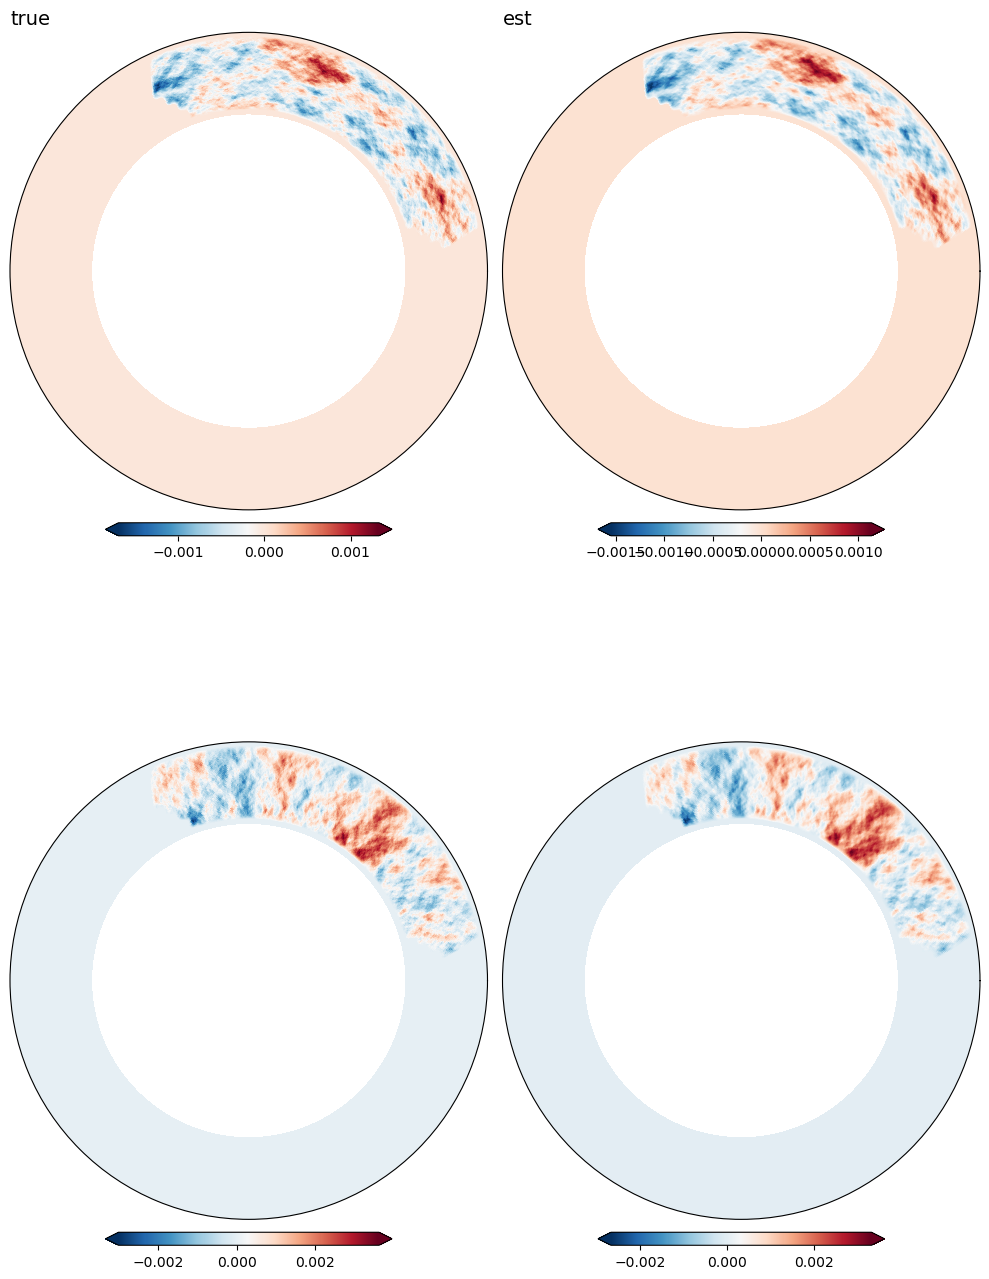

In [23]:
@sblock let ϕtru = ϕ, ϕest = ϕ_cr, ϕ2v!, φ, θ, hide_plots
    hide_plots && return
    viz = function (ϕ0)
        v = (deepcopy(ϕ0[:]), deepcopy(ϕ0[:]))
        ϕ2v!(v, ϕ0[:])
        v
    end
    imgs = Dict(1=>viz(ϕtru)[1], 3=>viz(ϕest)[1],
                2=>viz(ϕtru)[2], 4=>viz(ϕest)[2])
    txt  = Dict(1=>"true", 3=>"est")
    fig, ax = CMBrings.diskplot(
        imgs, φ', π.-θ; txt=txt,
        figsize=(10,16), nrows=2, fontsize=14
    )
    return nothing
end

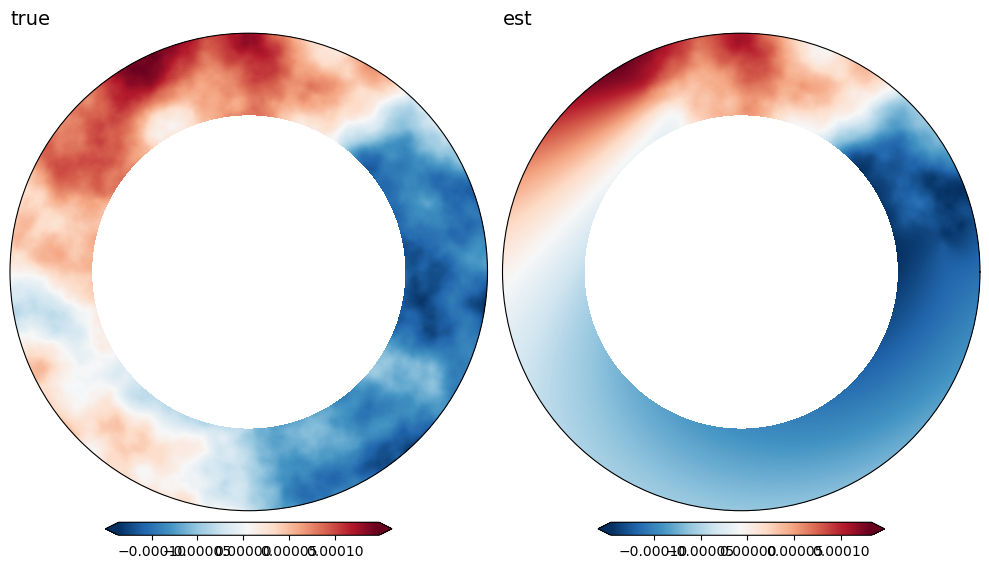

In [24]:
@sblock let ϕtru = ϕ, ϕest = ϕ_cr, ϕ2v!, φ, θ, hide_plots
    hide_plots && return
    imgs = Dict(1=>ϕtru[:], 2=>ϕest[:])
    txt  = Dict(1=>"true", 2=>"est")
    fig, ax = CMBrings.diskplot(
        imgs, φ', π.-θ; txt=txt,
        figsize=(10,8), nrows=1, fontsize=14
    )
    return nothing
end

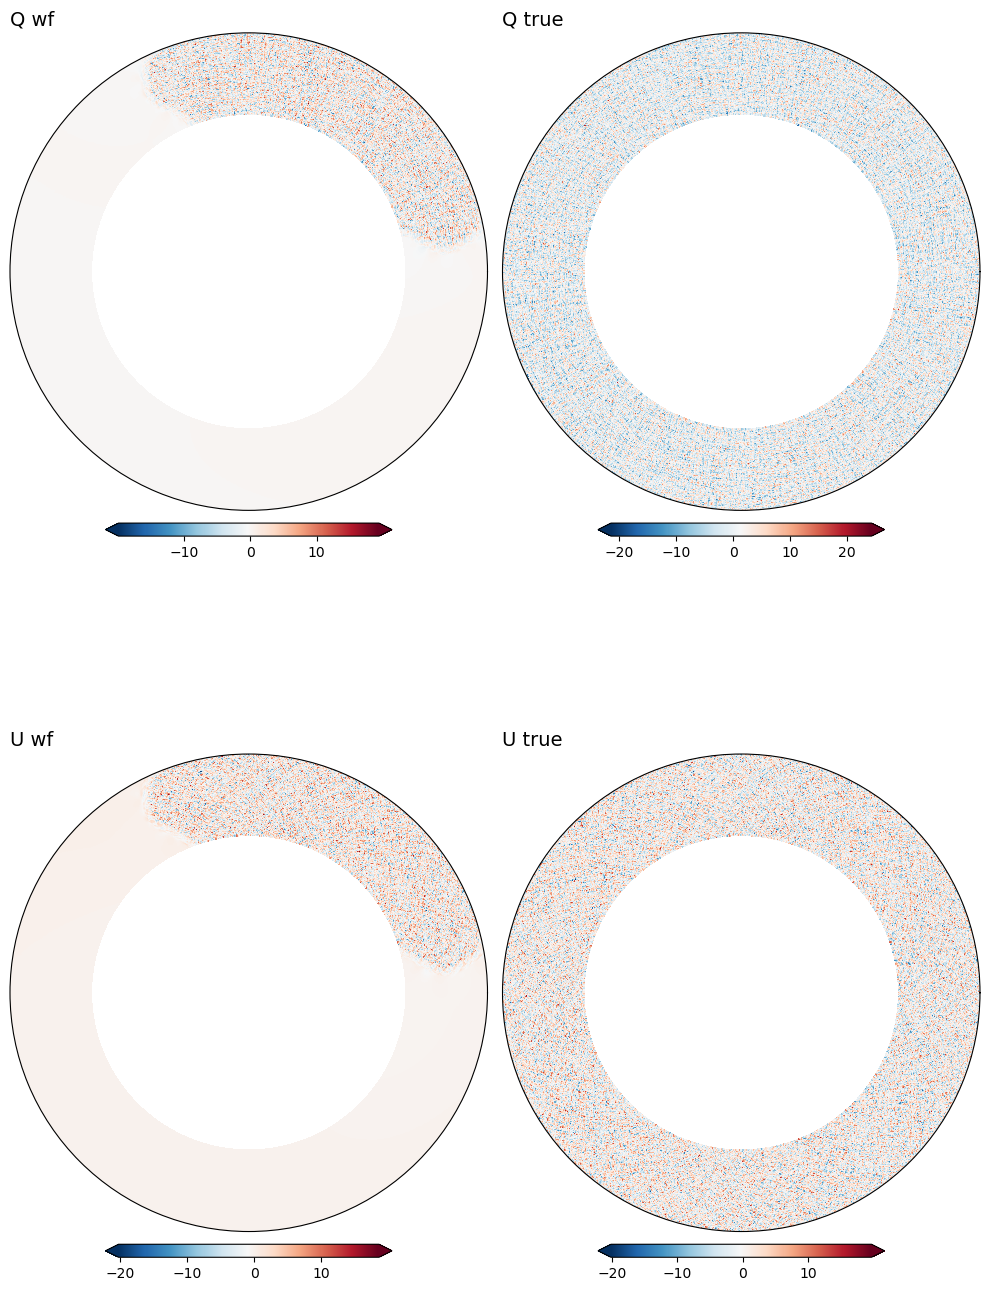

In [25]:
@sblock let f_cr, qu, φ, θ, hide_plots

    hide_plots && return

    imgs = Dict(1=>real(f_cr[:]), 2=>imag(f_cr[:]))
    imgs = Dict(
        1=>real(f_cr[:]), 2=>imag(f_cr[:]),
        3=>real(qu[:]),   4=>imag(qu[:])
        )
    txt  = Dict(
        1=>"Q wf",     2=>"U wf",
        3=>"Q true",   4=>"U true",
    )
    fig, ax = CMBrings.diskplot(
        imgs, φ', π.-θ; txt=txt,
        figsize=(10,16), nrows=2, fontsize=14
    )
    return nothing

end

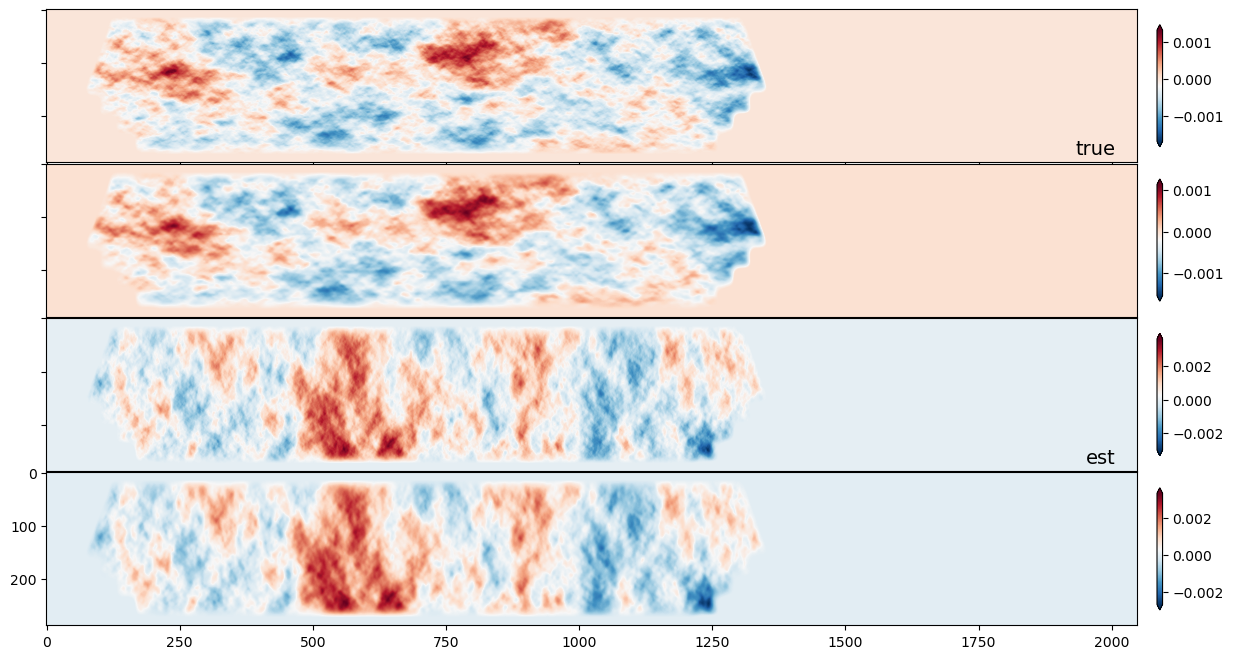

In [28]:
@sblock let ϕtru = ϕ, ϕest = ϕ_cr, ϕ2v!, φ, θ, hide_plots
    hide_plots && return
    viz = function (ϕ0)
        v = (deepcopy(ϕ0[:]), deepcopy(ϕ0[:]))
        ϕ2v!(v, ϕ0[:])
        v
    end
    imgs = Dict(1=>viz(ϕtru)[1], 2=>viz(ϕest)[1],
                3=>viz(ϕtru)[2], 4=>viz(ϕest)[2])
    txt  = Dict(1=>"true", 3=>"est")
    fig, ax = CMBrings.brickplot(
        imgs; txt=txt,
    )
    return nothing
end